# Неделя 1 - Профилирование данных и настройка среды

**Проект практики:** Анализ данных государственных закупок Республики Казахстан


## Цель Недели 1

Цель первой недели - подготовить техническую рабочую среду и выполнить **систематическое
профилирование данных** двух датасетов, которые будут использоваться на протяжении всей практики.

Профилирование данных - это процесс изучения исходных данных и сбора статистики и сводной информации
о них. Прежде чем выполнять очистку, преобразование или моделирование, необходимо понять:

1. **Структуру** каждого датасета (строки, столбцы, типы данных, объём памяти).
2. **Качество** данных (пропущенные значения, дубликаты, несогласованные форматы).
3. **Содержание** (распределения значений, кардинальность, ключевые поля).
4. **Связи** между двумя датасетами (как их можно соотнести).



In [1]:
# Основные импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Настройки отображения для читаемого вывода профилирования
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Среда готова.")
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

Среда готова.
pandas : 2.2.2
numpy  : 2.0.2


## 2. Загрузка датасетов

Оба файла в формате CSV (UTF-8, разделитель - запятая).

- **`suppliers`** - заявки, поданные по множеству категорий закупок.
- **`kraska`** - выборка по конкретной категории: все лоты по краске, с детальной информацией о ценах.


Небольшая вспомогательная функция оборачивает `pd.read_csv`, чтобы переиспользовать одну и ту же
логику загрузки (и вывод сообщений).


In [2]:
# Пути к файлам
PATH_SUPPLIERS = "suppliers.txt"          # содержимое CSV, расширение .txt
PATH_KRASKA    = "kraska.txt"             # содержимое CSV, расширение .txt

def load_csv(path, name):
    """Загрузить CSV-файл и вывести однострочное подтверждение загрузки (служит лог-записью)."""
    df = pd.read_csv(path)
    print(f"[ЗАГРУЗКА] {name:<12} -> {df.shape[0]:>7,} строк  x  {df.shape[1]:>2} столбцов")
    return df

suppliers = load_csv(PATH_SUPPLIERS, "suppliers")
kraska    = load_csv(PATH_KRASKA, "kraska")

[ЗАГРУЗКА] suppliers    -> 107,518 строк  x  12 столбцов
[ЗАГРУЗКА] kraska       ->  49,123 строк  x  16 столбцов


### Первый взгляд на данные

Просматриваем первые строки каждого датасета, чтобы визуально убедиться в корректной загрузке
столбцов и составить представление о содержании.


In [3]:
suppliers.head(3)

,Номер лота,Заказчик,Дата заявки,Год,Статус заявки,Сумма заявки,Код КТРУ,Наименование КТРУ,Описание КТРУ,Сумма лота,Дата окончания лота,Результат
0,53534672-ОК1,"ГУ ""Отдел пассажирского транспорта и автомобил...",2022-08-19 09:13:07,2022,Второй победитель,"76339446,9",421120.210.000002,Работы по ремонту автомобильной дороги,Работы по ремонту/реконструкции автомобильной ...,"80357312,5",2022-08-19 07:00:03,NaN
1,56352063-ЗЦП1,"Астана қаласы әкімдігінің ""Мағжан Жұмабаев аты...",2023-01-06 12:06:08,2023,Подано,870000,620920.000.000013,Услуги по предоставлению доступа к информацион...,Услуги по предоставлению доступа к информацион...,870000,2023-01-13 04:35:00,NaN
2,57054440-ЗЦП1,Шығыс Қазақстан облысы білім басқармасы Өскеме...,2023-01-10 15:20:36,2023,Второй победитель,580000,620920.000.000013,Услуги по предоставлению доступа к информацион...,Услуги по предоставлению доступа к информацион...,580000,2023-01-16 05:45:38,NaN


In [4]:
kraska.head(3)

,Дата публикации,LotId,Номер лота,КТРУ,Наименование лота,Наименование КТРУ,Описание КТРУ,Наименование заказчика,БИН заказчика,Количество,Сумма лота,Цена заявки,Сумма заявки,StatusId,StatusName,Результат
0,2026-02-27 00:24:19,40370497,85655195-ОИ2,203023.700.000000,Краска,Краска,акварельная,Государственное коммунальное казенное предприя...,340004607,2.00,"6,370.00","2,100.00","4,200.00",8,Допущено,Участник
1,2026-02-26 13:14:30,40300054,85351286-ОИ4,203011.900.000000,Краска,Краска,акриловая,"ГККП ""Кентауский многопрофильный колледж"" упра...",991240001864,1.00,"9,500.00","9,500.00","9,500.00",8,Допущено,Участник
2,2026-02-26 13:14:30,40300054,85351286-ОИ4,203011.900.000000,Краска,Краска,акриловая,"ГККП ""Кентауский многопрофильный колледж"" упра...",991240001864,1.00,"9,500.00","9,500.00","9,500.00",8,Допущено,Участник


## 3. Структурное профилирование

Для каждого датасета фиксируем **размер**, **объём занимаемой памяти** и **типы данных по столбцам**.
Это структурная базовая линия модели данных.


In [7]:
def structural_summary(df, name):
    print(f"{name.upper()} ")
    print(f"Строк        : {df.shape[0]:,}")
    print(f"Столбцов     : {df.shape[1]}")
    mem = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"Память (МБ)  : {mem:,.2f}")
    print(f"Дубликаты    : {df.duplicated().sum():,}")
    print("-" * 40)
    print("Типы данных по столбцам:")
    print(df.dtypes.to_string())
    print()

structural_summary(suppliers, "suppliers")
structural_summary(kraska, "kraska")

SUPPLIERS 
Строк        : 107,518
Столбцов     : 12
Память (МБ)  : 110.41
Дубликаты    : 23,643
----------------------------------------
Типы данных по столбцам:
Номер лота             object
Заказчик               object
Дата заявки            object
Год                     int64
Статус заявки          object
Сумма заявки           object
Код КТРУ               object
Наименование КТРУ      object
Описание КТРУ          object
Сумма лота             object
Дата окончания лота    object
Результат              object

KRASKA 
Строк        : 49,123
Столбцов     : 16
Память (МБ)  : 63.58
Дубликаты    : 4,818
----------------------------------------
Типы данных по столбцам:
Дата публикации            object
LotId                       int64
Номер лота                 object
КТРУ                       object
Наименование лота          object
Наименование КТРУ          object
Описание КТРУ              object
Наименование заказчика     object
БИН заказчика               int64
Количество     

### Построение переиспользуемого профиля столбцов

Одна функция строит аккуратную таблицу профилирования для каждого датасета: для каждого столбца она
показывает тип данных, количество и процент пропущенных значений, а также число уникальных значений
(кардинальность).


In [8]:
def column_profile(df):
    profile = pd.DataFrame({
        "тип": df.dtypes.astype(str),
        "не_пустых": df.notnull().sum(),
        "пропусков": df.isnull().sum(),
        "пропусков_%": (df.isnull().sum() / len(df) * 100).round(1),
        "уникальных": df.nunique(),
        "уникальных_%": (df.nunique() / len(df) * 100).round(1),
    })
    return profile.sort_values("пропусков_%", ascending=False)

print("SUPPLIERS - профиль столбцов")
column_profile(suppliers)

SUPPLIERS - профиль столбцов


,тип,не_пустых,пропусков,пропусков_%,уникальных,уникальных_%
Результат,object,16494,91024,84.70,1,0.00
Наименование КТРУ,object,103835,3683,3.40,1754,1.60
Описание КТРУ,object,103835,3683,3.40,3027,2.80
Код КТРУ,object,105457,2061,1.90,3599,3.30
Дата окончания лота,object,106916,602,0.60,14663,13.60
Сумма заявки,object,107454,64,0.10,11477,10.70
Заказчик,object,107517,1,0.00,8795,8.20
Номер лота,object,107518,0,0.00,26340,24.50
Год,int64,107518,0,0.00,4,0.00
Дата заявки,object,107518,0,0.00,18827,17.50


In [9]:
print("KRASKA - профиль столбцов")
column_profile(kraska)

KRASKA - профиль столбцов


,тип,не_пустых,пропусков,пропусков_%,уникальных,уникальных_%
Дата публикации,object,49123,0,0.00,8114,16.50
LotId,int64,49123,0,0.00,11587,23.60
Номер лота,object,49123,0,0.00,11584,23.60
КТРУ,object,49123,0,0.00,24,0.00
Наименование лота,object,49123,0,0.00,283,0.60
Наименование КТРУ,object,49123,0,0.00,2,0.00
Описание КТРУ,object,49123,0,0.00,24,0.00
Наименование заказчика,object,49123,0,0.00,5286,10.80
БИН заказчика,int64,49123,0,0.00,4906,10.00
Количество,float64,49123,0,0.00,441,0.90


## 4. Анализ пропущенных значений

Пропущенные данные - одно из важнейших измерений качества. Визуализируем процент пропусков по
столбцам, чтобы приоритеты очистки для Недели 2 стали очевидны.

**Ключевое наблюдение:** в датасете `suppliers` столбец `Результат` ожидаемо почти пустой, потому
что результат появляется только после завершения тендера - многие строки относятся к ещё открытым
заявкам.


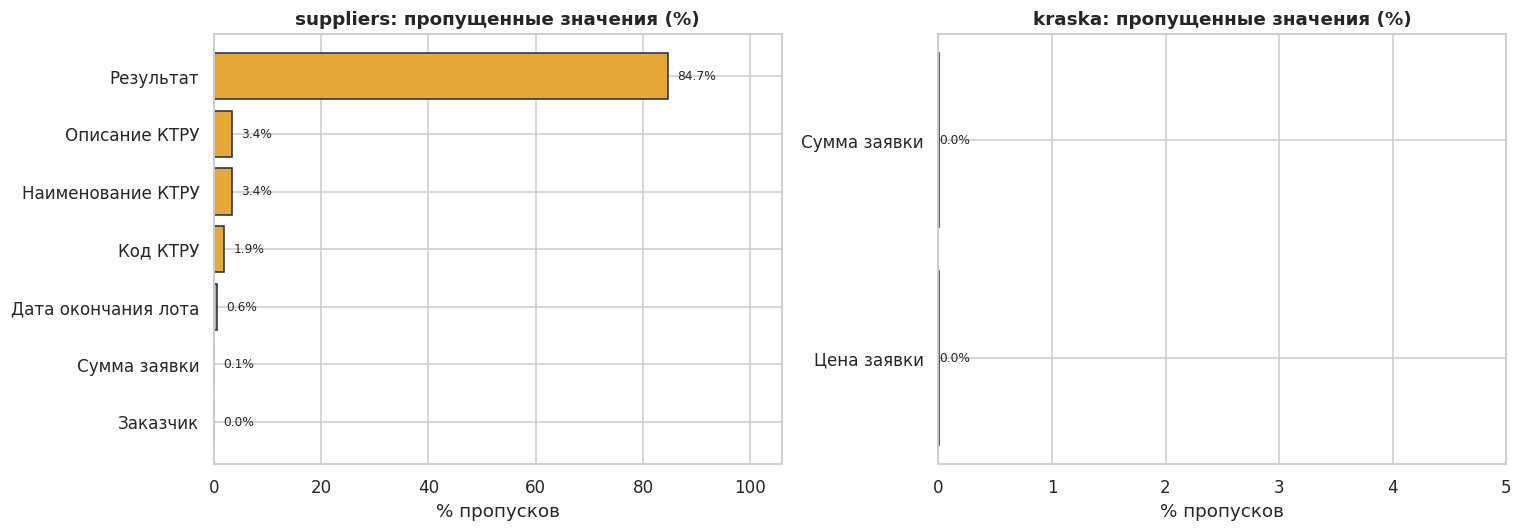

In [13]:
def plot_missing(df, name, ax):
    nulls = (df.isnull().sum() / len(df) * 100)
    nulls = nulls[nulls > 0].sort_values()
    ax.barh(nulls.index, nulls.values, color="#E8A838", edgecolor="#1B2A4A")
    ax.set_title(f"{name}: пропущенные значения (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("% пропусков")
    ax.set_xlim(0, max(nulls.max() * 1.25, 5))   # фиксированный запас, чтобы подписи помещались
    for i, v in enumerate(nulls.values):
        ax.text(v + nulls.max() * 0.02, i, f"{v:.1f}%", va="center", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_missing(suppliers, "suppliers", axes[0])
plot_missing(kraska, "kraska", axes[1])
plt.tight_layout()
plt.savefig("неделя_1_пропущенные_значения.png", dpi=130)
plt.show()

### Интерпретация пропущенных значений

- **suppliers.`Результат` (~85% пропусков):** Это *структурная* особенность, а не ошибка. Результат
  записывается только когда тендер завершается. Этот столбец потребует аккуратной обработки в будущем -
  его нельзя просто удалить или бездумно заполнить.
- **suppliers.`Наименование КТРУ` / `Описание КТРУ` (~3.4%):** Метаданные категории отсутствуют для
  части лотов; кандидат на восстановление из поля `Код КТРУ`.
- **kraska.`Цена заявки` / `Сумма заявки` (2 строки):** Незначительное число пропущенных значений цены;
  эти строки можно безопасно удалить во время очистки в будущем.



## 5. Проблемы типов данных и форматов

Профилирование - это не только пропуски. Нужно выявить столбцы, чей **хранимый тип не соответствует
смысловому типу** - классический источник ошибок в любом конвейере данных.

В `suppliers` есть критическая проблема: денежные столбцы `Сумма заявки` и `Сумма лота` хранятся как
**текст**, потому что используют **запятую в качестве десятичного разделителя** (например,
`76339446,9`). Их необходимо привести к числовому типу перед любой статистикой или моделированием.


In [14]:
# Демонстрация проблемы формата
print("Пример сырых значений 'Сумма заявки' (хранятся как текст, десятичная запятая):")
print(suppliers["Сумма заявки"].dropna().head(5).tolist())
print()
print("Текущий тип:", suppliers["Сумма заявки"].dtype)

Пример сырых значений 'Сумма заявки' (хранятся как текст, десятичная запятая):
['76339446,9', '870000', '580000', '600000', '90000']

Текущий тип: object


In [18]:
def to_numeric_kz(series):
  # Преобразовать денежный текстовый столбец в формате КЗ в float
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)  # неразрывные пробелы
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Предпросмотр преобразования (без изменения исходных данных: работаем с копией)
preview = to_numeric_kz(suppliers["Сумма заявки"])
print("После преобразования - тип:", preview.dtype)
print()
print("Описательная статистика суммы заявки (тенге):")
print(preview.describe().apply(lambda x: f"{x:,.0f}"))

После преобразования - тип: float64

Описательная статистика суммы заявки (тенге):
count        107,454
mean       1,048,168
std       10,001,065
min                0
25%            7,750
50%           33,300
75%          182,872
max      556,827,629
Name: Сумма заявки, dtype: object


Преобразование проходит успешно и сразу даёт осмысленную статистику (минимум, максимум, квартили
сумм заявок в тенге).


## 6. Профилирование содержания - категориальные распределения

Изучаем ключевые категориальные поля, которые будут определять дальнейший анализ: **статус заявки** и
**год** тендера. Понимание этих распределений показывает, насколько сбалансированы данные - что очень
важно для прогностической модели в Неделе 3.


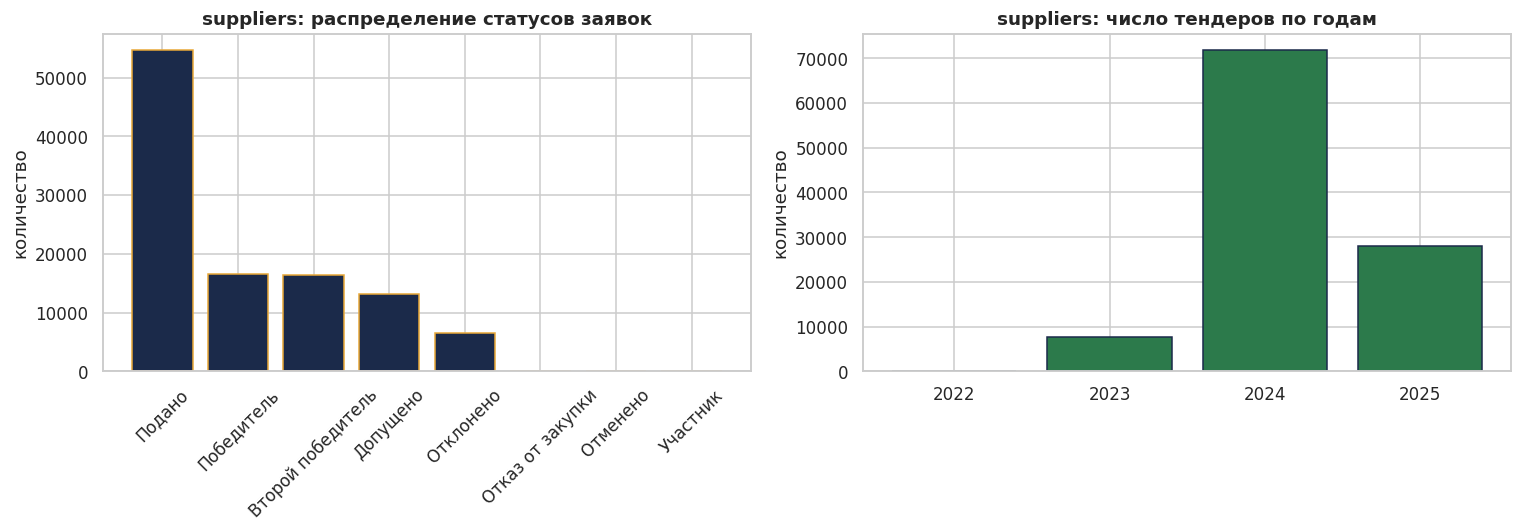

In [19]:
# Распределение статусов в suppliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = suppliers["Статус заявки"].value_counts()
axes[0].bar(status_counts.index, status_counts.values,
            color="#1B2A4A", edgecolor="#E8A838")
axes[0].set_title("suppliers: распределение статусов заявок", fontweight="bold")
axes[0].set_ylabel("количество")
axes[0].tick_params(axis="x", rotation=45)

year_counts = suppliers["Год"].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color="#2C7A4B", edgecolor="#1B2A4A")
axes[1].set_title("suppliers: число тендеров по годам", fontweight="bold")
axes[1].set_ylabel("количество")

plt.tight_layout()
plt.savefig("неделя1_распределение.png", dpi=130)
plt.show()

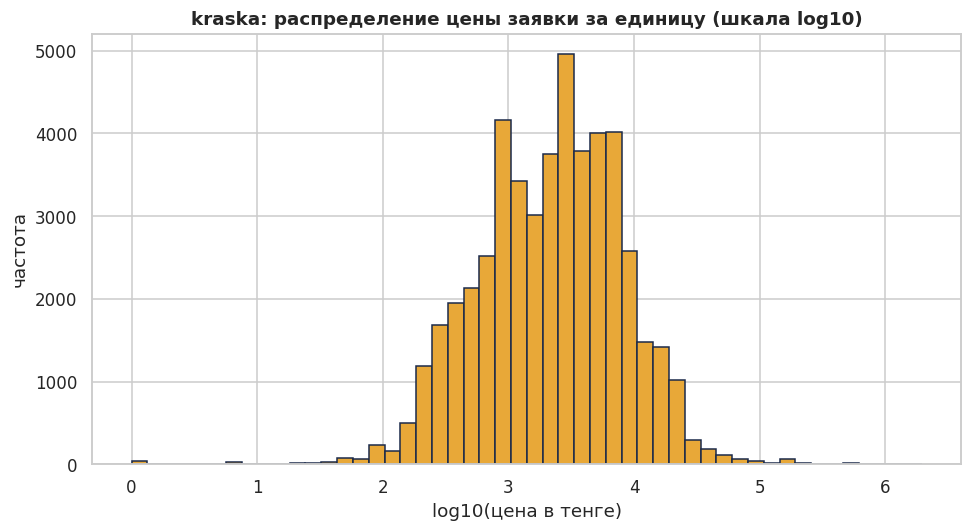

Сводка по цене (тенге):
count       49,121.00
mean         5,390.79
std         25,963.48
min              1.00
25%            888.00
50%          2,430.00
75%          5,600.00
max      1,956,000.00
Name: Цена заявки, dtype: object


In [20]:
# Числовое распределение в kraska - цена за единицу (логарифмическая шкала из-за сильной скошенности)
price = kraska["Цена заявки"].dropna()
price = price[price > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(np.log10(price), bins=50, color="#E8A838", edgecolor="#1B2A4A")
ax.set_title("kraska: распределение цены заявки за единицу (шкала log10)", fontweight="bold")
ax.set_xlabel("log10(цена в тенге)")
ax.set_ylabel("частота")
plt.tight_layout()
plt.savefig("неделя1_ценовое_распределение.png", dpi=130)
plt.show()

print("Сводка по цене (тенге):")
print(price.describe().apply(lambda x: f"{x:,.2f}"))

Распределение цен **сильно скошено вправо** (поэтому используется логарифмическая шкала). Это
важная находка для будущей регрессионной модели, вероятно, понадобится логарифмическое
преобразование целевой переменной, а также потребуется обработка выбросов.


## 7. Связь между двумя датасетами

Оба датасета описывают заявки на закупки и имеют общие структурные ключи на **уровне лота / тендера**
(`Номер лота`) и пересекающиеся описательные поля (коды категорий КТРУ, организация-заказчик, суммы).
Поскольку прямые идентификаторы поставщиков не были даны в целях конфиденциальности, датасеты связываются через
**атрибуты уровня лота и категории**, а не через персональный идентификатор.


In [21]:
# Пересечение кодов категорий КТРУ между двумя датасетами
ktru_suppliers = set(suppliers["Код КТРУ"].dropna().astype(str).unique())
ktru_kraska    = set(kraska["КТРУ"].dropna().astype(str).unique())

overlap = ktru_suppliers & ktru_kraska

print(f"Уникальных кодов КТРУ в 'suppliers': {len(ktru_suppliers):,}")
print(f"Уникальных кодов КТРУ в 'kraska'   : {len(ktru_kraska):,}")
print(f"Коды КТРУ, присутствующие в ОБОИХ  : {len(overlap):,}")

Уникальных кодов КТРУ в 'suppliers': 3,599
Уникальных кодов КТРУ в 'kraska'   : 24
Коды КТРУ, присутствующие в ОБОИХ  : 19


### Логическая модель данных

Профилирование выявляет следующую концептуальную связь. Каждая запись описывает **Заявку (Bid)**,
поданную на **Лот / Тендер**, который выпущен организацией-**Заказчиком** и классифицирован кодом
категории **КТРУ**. После удаления персональных идентификаторов поставщиков модель организована вокруг
измерений лота и категории.

```
   +---------------------------+        +---------------------------+
   |        ЗАЯВКА (BID)       |        |      ЛОТ / ТЕНДЕР          |
   |---------------------------|        |---------------------------|
   | сумма заявки              |  * 1   | номер лота      (PK)      |
   | статус                    |------->| заказчик                  |
   | дата заявки               |        | сумма лота                |
   | результат                 |        | дата окончания            |
   | номер лота      (FK) -----+        | код КТРУ        (FK)      |
   +---------------------------+        +-------------+-------------+
                                                      |
                                                      | *
                                                      v
                                          +---------------------------+
                                          |      КАТЕГОРИЯ КТРУ       |
                                          |---------------------------|
                                          | код КТРУ        (PK)      |
                                          | наименование КТРУ         |
                                          | описание КТРУ             |
                                          +---------------------------+

Общие связующие измерения в обоих датасетах:  номер лота  +  код категории КТРУ
```

Эта логическая модель определяет, как два файла можно очистить в хорошо структурированные таблицы и как их можно соотнести для более глубокого анализа.


## 8. Архитектура потока данных проекта

Диаграмма ниже показывает запланированный поток данных для всей практики. Неделя 1 покрывает этап
**Профилирования**; последующие недели строятся на этой базовой линии.

```
   ┌─────────────────────┐
   │   ИСТОЧНИК ДАННЫХ   │   выданные датасеты
   │   гос. закупки      │
   └──────────┬──────────┘
              │  выгрузка сырого CSV
              v
   ┌─────────────────────┐
   │   СЫРОЙ СЛОЙ        │   suppliers.csv  +  kraska.csv
   │   (файлы как есть)  │
   └──────────┬──────────┘
              │
              v
   ┌────────────────────────┐
   │ НЕДЕЛЯ 1: ПРОФИЛИРОВ   │
   │   • структура          │      pandas / numpy
   │   • качество (пропуски)│     matplotlib / seaborn
   │   • содержание         │      - базовая линия + список задач очистки
   └──────────┬─────────────┘
              │
              v
   ┌──────────────────────┐
   │   НЕДЕЛЯ 2: ETL      │      извлечение -> преобразование -> загрузка
   │   • исправление типов│      (числовые касты, дедупликация)            
   │   • очистка          │
   └──────────┬───────────┘
              │
              v
   ┌─────────────────────┐
   │ НЕДЕЛЯ 3: АНАЛИЗ    │      EDA + статистические тесты
   │   И МОДЕЛИРОВАНИЕ   │      прогностическая модель (регрессия/классиф.)
   └──────────┬──────────┘
              │
              v
   ┌─────────────────────┐
   │ НЕДЕЛЯ 4: СДАЧА     │      оптимизация, документация, GitHub-репозиторий
   └─────────────────────┘
```


## 9. Итоги Недели 1 и находки

**Что выполнено**

1. Подготовлена и проверена рабочая среда (Python, pandas, NumPy, Matplotlib, Seaborn, Jupyter).
2. Загружены и структурно профилированы оба датасета.
3. Реализована и применена к обоим датасетам переиспользуемая функция профилирования столбцов.
4. Выполнено профилирование пропусков, типов данных и содержания, графики сохранены как доказательства.
5. Задокументированы связь между датасетами (общий ключ: номер лота + категория КТРУ) и логическая модель данных.
6. Определена полная архитектура потока данных проекта.

**Ключевые находки для Недели 2 (список задач очистки)**

| # | Находка | Действие в Неделе 2 |
|---|---------|---------------------|
| 1 | `suppliers`: денежные столбцы хранятся как текст с десятичными запятыми | Привести к числовому типу в ETL |
| 2 | `suppliers.Результат` ~85% пропусков (структурно) | Определить явную политику пропусков; не заполнять бездумно |
| 3 | `suppliers`: ~23,600 дубликатов строк | Дедупликация с задокументированным ключом |
| 4 | `kraska`: ~4,800 дубликатов строк | Дедупликация |
| 5 | `suppliers`: поля категории КТРУ ~3.4% пропусков | Восстановить наименование из кода КТРУ, где возможно |
| 6 | `kraska` цена/сумма сильно скошены вправо | Запланировать лог-преобразование и обработку выбросов для моделирования |

